In [161]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline

## <u>Load Dataset</u>

In [150]:
titanic = sns.load_dataset("titanic")
titanic.head() # binary classification 
# titanic_data["embarked"].nunique()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [151]:
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## <u>Data cleaning</u>
- Order:-
  
    1. Drop Bad Columns
    2. Impute Categorical Features (SimpleImputer)
       - df[["col"]] = SimpleImputer().fit_transform(df[["col"]]) 
    4. Encode Categorical Features (LabelEncoder or OneHotEncoder)
       - LabelEncoder().fit_transform(df["col"])
    5. Impute Numeric Features (KNNImputer)



In [152]:
# 1. drop the columns that are redundant and has too many null vaues
titanic_data = titanic.drop(columns=["deck", "alive", "class", "embark_town", "who", "adult_male"])

# 2. fill the empty cell using simple imputer imputer
    # we use simple imputer to fill in the the embarked column as it has only 2 empty columns
    # simple imputer expects a 2d df/array so we pass even a single column as df[[]]
simple_imputer = SimpleImputer(strategy="most_frequent")
titanic_data[["embarked"]] = simple_imputer.fit_transform(titanic_data[["embarked"]]) # 2d DataFrame grid (1 column, many rows)

# 3. encode categorical values
    # generally we use onehotencoder for X and labelencoder for y, but in DT, both work as the splitting is done based on threshold
    # as label encoder was made for y, it expects only a 1d array/series df[]
    # onehotencoder and pd.get_dummies do the same thing but onehotencoder handles new data values nicely and prevents data leakage
le = LabelEncoder()
titanic_data["embarked"] = le.fit_transform(titanic_data["embarked"])
titanic_data["sex"] = le.fit_transform(titanic_data["sex"]) 

# 4. fill the empty cell using simple imputer imputer 
    # we use a knn imputer for age cuz its numeric value with 177 null values 
    # we dont use knn imputer on categorical data without encoding as it needs the whole dataset rather than just one column 
    # we take k = 5 
    # the steps are :-
        # A. Initialize the imputer
        # B. Fit and transform the WHOLE numerical dataframe as KNN needs the other cols to calculate the dist and find neighbors
        # C. Put it back into a DataFrame with the original column headers
knn_imputer = KNNImputer(n_neighbors=5)

titanic_data_imputed = knn_imputer.fit_transform(titanic_data)

# the output here can be a mismatch with the columns as the knn_imputer might have updated it, dont worry so much about it
titanic_data = pd.DataFrame(titanic_data_imputed, columns=titanic_data.columns) 

In [153]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0.0,3.0,1.0,22.0,1.0,0.0,7.2500,2.0,0.0
1,1.0,1.0,0.0,38.0,1.0,0.0,71.2833,0.0,0.0
2,1.0,3.0,0.0,26.0,0.0,0.0,7.9250,2.0,1.0
3,1.0,1.0,0.0,35.0,1.0,0.0,53.1000,2.0,0.0
4,0.0,3.0,1.0,35.0,0.0,0.0,8.0500,2.0,1.0


In [154]:
titanic_data.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

## <u>Data split</u>

In [155]:
X = titanic_data.drop(columns = ["survived"])
y = titanic_data["survived"] # 1d series

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## <u>Create, train and predict the Decision Trees Classifier model (no pruning)</u>

In [156]:
# create
model = DecisionTreeClassifier() # uses gini impurity by default (CART)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

## <u>Evaluate</u>

In [157]:
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred)) # inversely propotional with precision
print("F1 Score : ", f1_score(y_test, y_pred)) # balances recall and precision
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

Accuracy :  0.7821229050279329
Precision :  0.7160493827160493
Recall :  0.7837837837837838
F1 Score :  0.7483870967741936

Confusion Matrix : 
 [[82 23]
 [16 58]]


## <u>plotting the decision tree</u>

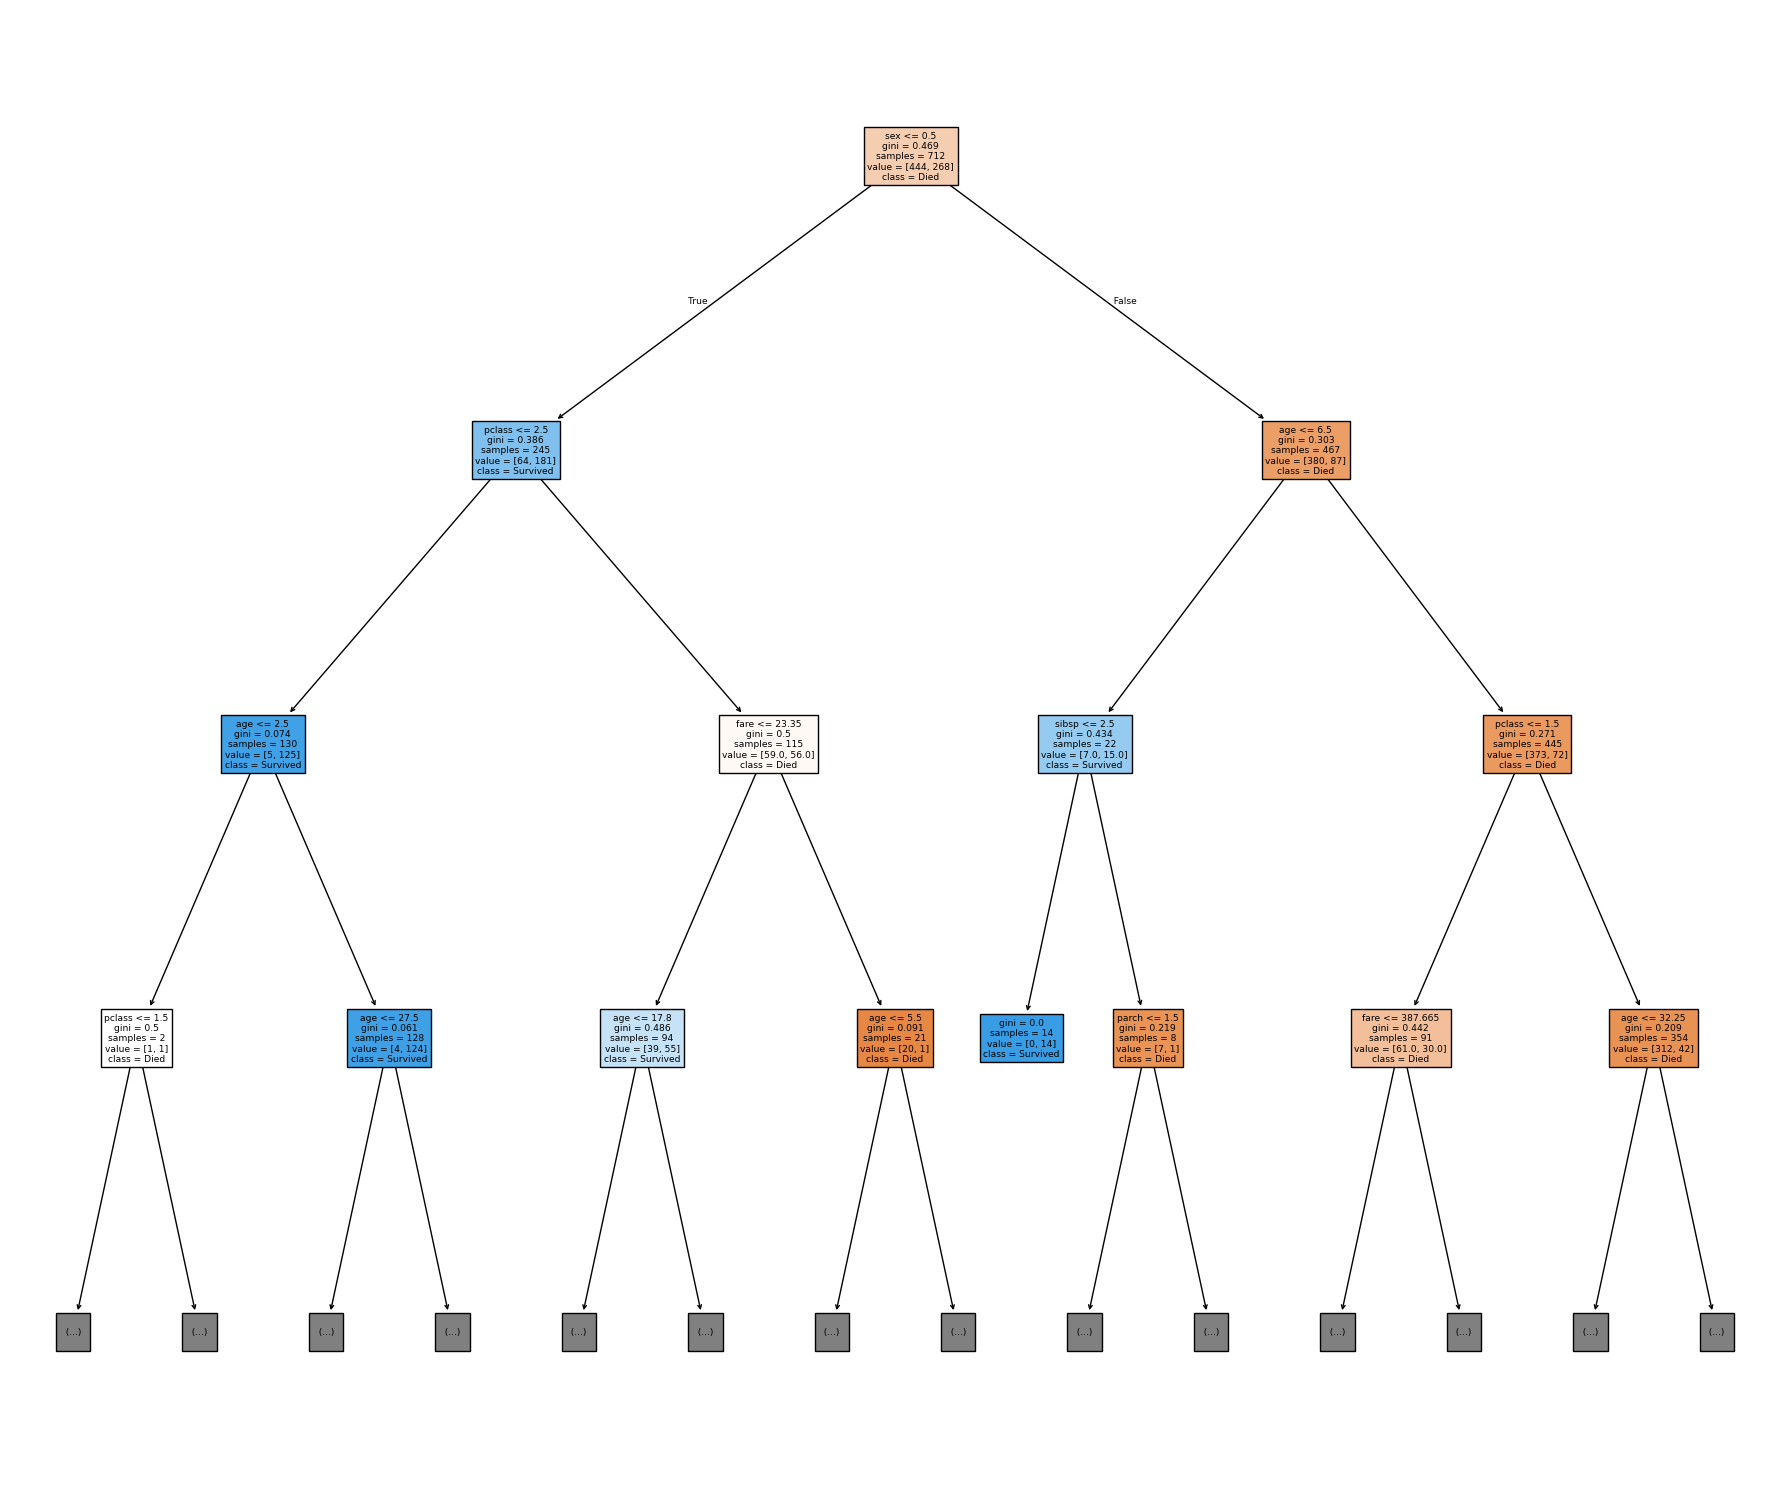

In [159]:
# 1. define the figure size
plt.figure(figsize=(18,15))

# 2. create the plot
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"], # define what does 1 and 0 mean in our label class
    filled = True,
    max_depth = 3 # if we want to zoom in the first n levels
)

plt.tight_layout()
plt.show()

# findings : sex is feature in the root node meaning its the most import follewed by pclass and age at level-2

- findings :-
    1. sex is feature in the root node meaning its the most important followed by pclass and age at level-2
    2. by Level-3 some of the leaf nodes already were around majority
    3. total samples are 712 (80%)

## <u>Decision Trees with Pre-Pruning</u>

Best Depth: {'dt__max_depth': 6, 'dt__min_samples_split': 10}
Best Grid Search Accuracy: 0.8230572244656751
Final Test Accuracy: 0.8044692737430168


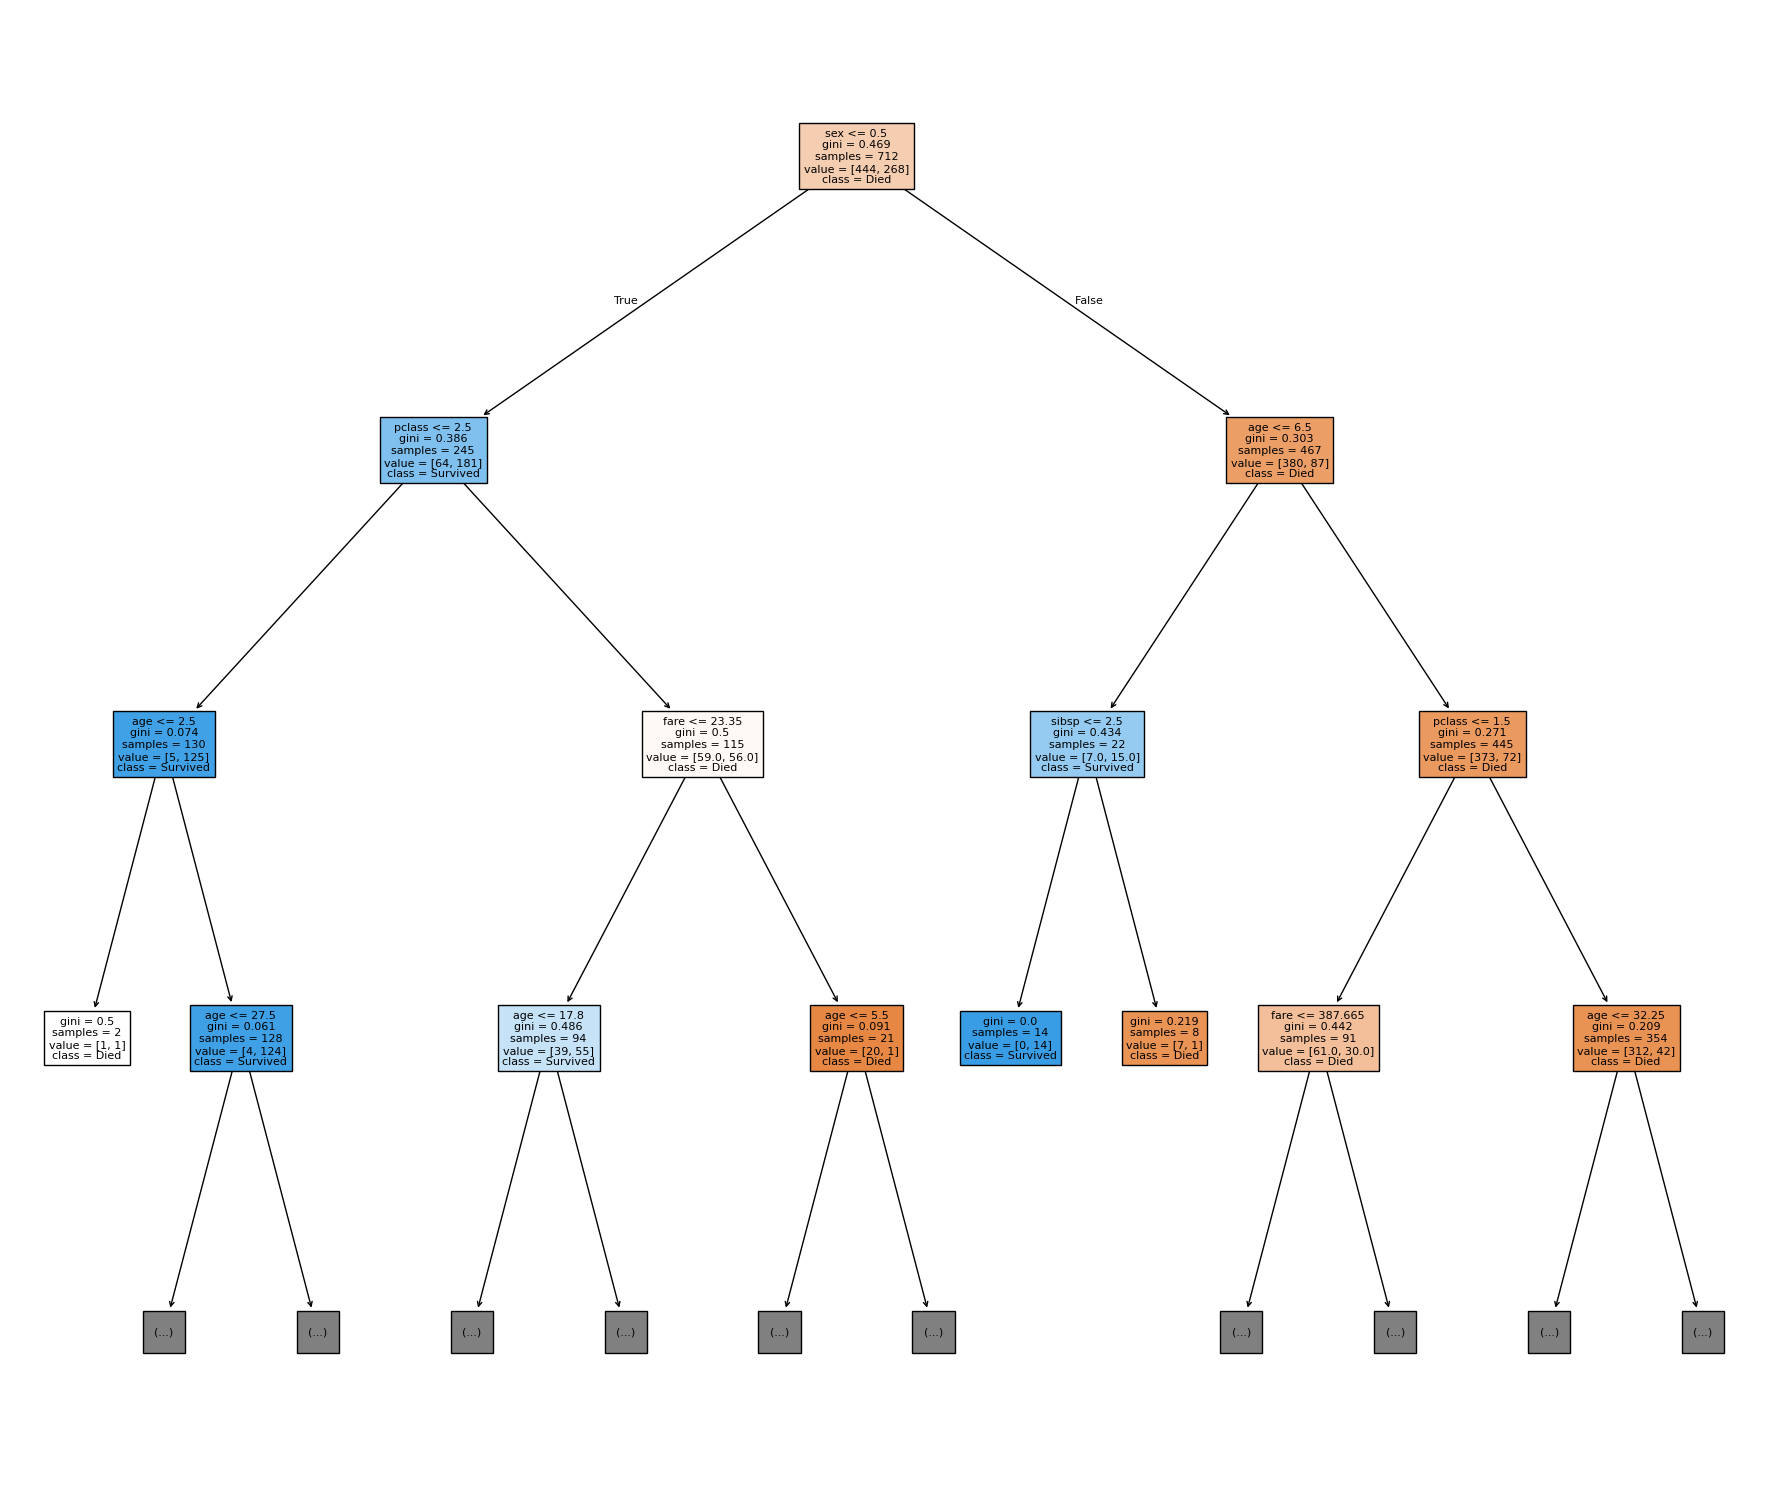

,param_dt__max_depth,param_dt__min_samples_split,mean_test_score
0,2,5,0.786467
1,2,10,0.786467
2,2,15,0.786467
3,2,20,0.786467
4,2,25,0.786467
5,2,30,0.786467
6,3,5,0.820211
7,3,10,0.820211
8,3,15,0.814587
9,3,20,0.814587


In [201]:
# we put some pruning conditions for the decision tree when we are making it 
# we can use a loop but that leads to data leakage so we make a proper pipeline and use gridsearch cv to find the best hyperparam

# 1. make pipeline
steps = [("dt", DecisionTreeClassifier(random_state=42))] # the steps, here random state 42 makes sure there is no randomness
dt_pipeline = Pipeline(steps)

# 2. Set up the parameter grid
param_grid = {
    "dt__max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10], # dt__ makes sure that the max depth list goes in as a hyperparameter while creating
    "dt__min_samples_split": [5, 10, 15, 20, 25, 30] 
}

# 3. Create the GridSearchCV 
dt_classifier_cv = GridSearchCV(
    dt_pipeline, 
    param_grid, 
    cv=5, # scoring by default is accuracy
)

# 4. Fit and predict
dt_classifier_cv.fit(X_train, y_train)
y_pred = dt_classifier_cv.predict(X_test)

print("Best Depth:", dt_classifier_cv.best_params_) # prints the best max_depth and best min_samples_split based on the accuracy 
print("Best Grid Search Accuracy:", dt_classifier_cv.best_score_) # prints the accuracy of best max_depth and best min_samples_split

print("Final Test Accuracy:", dt_classifier_cv.score(X_test, y_test)) # the accuracy of the model on the test data
                                                                      # we could use .accuracy_score as well but this is a shortcut

# 5. Plot using the extracted tree model
plt.figure(figsize=(18,15))
best_pipeline = dt_classifier_cv.best_estimator_ # Extract the best trained pipeline from GridSearchCV
best_dt = best_pipeline.named_steps["dt"] # Extract the actual Decision Tree classifier from the best pipeline using the string "dt"

plot_tree(
    best_dt,
    feature_names = X.columns,
    class_names = ["Died", "Survived"], 
    filled = True,
    max_depth = 3 # makes sure even if bestmax_depth = 10, then too show only the top 3 levels as its neat for human eye
)

plt.tight_layout()
plt.show()

# prints the test score for all the possible combination of max_depth and min_samples_split of the gridsearchcv
pd.DataFrame(dt_classifier_cv.cv_results_)[["param_dt__max_depth", "param_dt__min_samples_split", "mean_test_score"]]

## <u>Decision Trees with Post-Pruning</u>

[0.         0.         0.00023408 0.00042135 0.00046816 0.00046816
 0.00046816 0.00053505 0.00063537 0.00066799 0.00070225 0.00078027
 0.00080257 0.00081929 0.00086945 0.00090289 0.00092463 0.00093633
 0.00100988 0.00102938 0.00107009 0.00108347 0.0011236  0.0011236
 0.0011236  0.00113448 0.00120385 0.00122893 0.00122893 0.00123365
 0.00130996 0.00131329 0.00133761 0.00133761 0.0013502  0.00135509
 0.00136193 0.00145651 0.00149813 0.00149813 0.00149813 0.00154494
 0.00160514 0.00162817 0.00172806 0.00187266 0.00187266 0.00187266
 0.00187266 0.00191167 0.00194897 0.00255363 0.00275792 0.00278189
 0.00286588 0.00308069 0.00371532 0.00588574 0.0090554  0.01094867
 0.01392951 0.01592416 0.03860535 0.13777998]

Best model (Alpha) :  {'dt__ccp_alpha': np.float64(0.005885739495381008)}
Best Grid Search Accuracy: 0.817393873731902
Final Test Accuracy: 0.7988826815642458


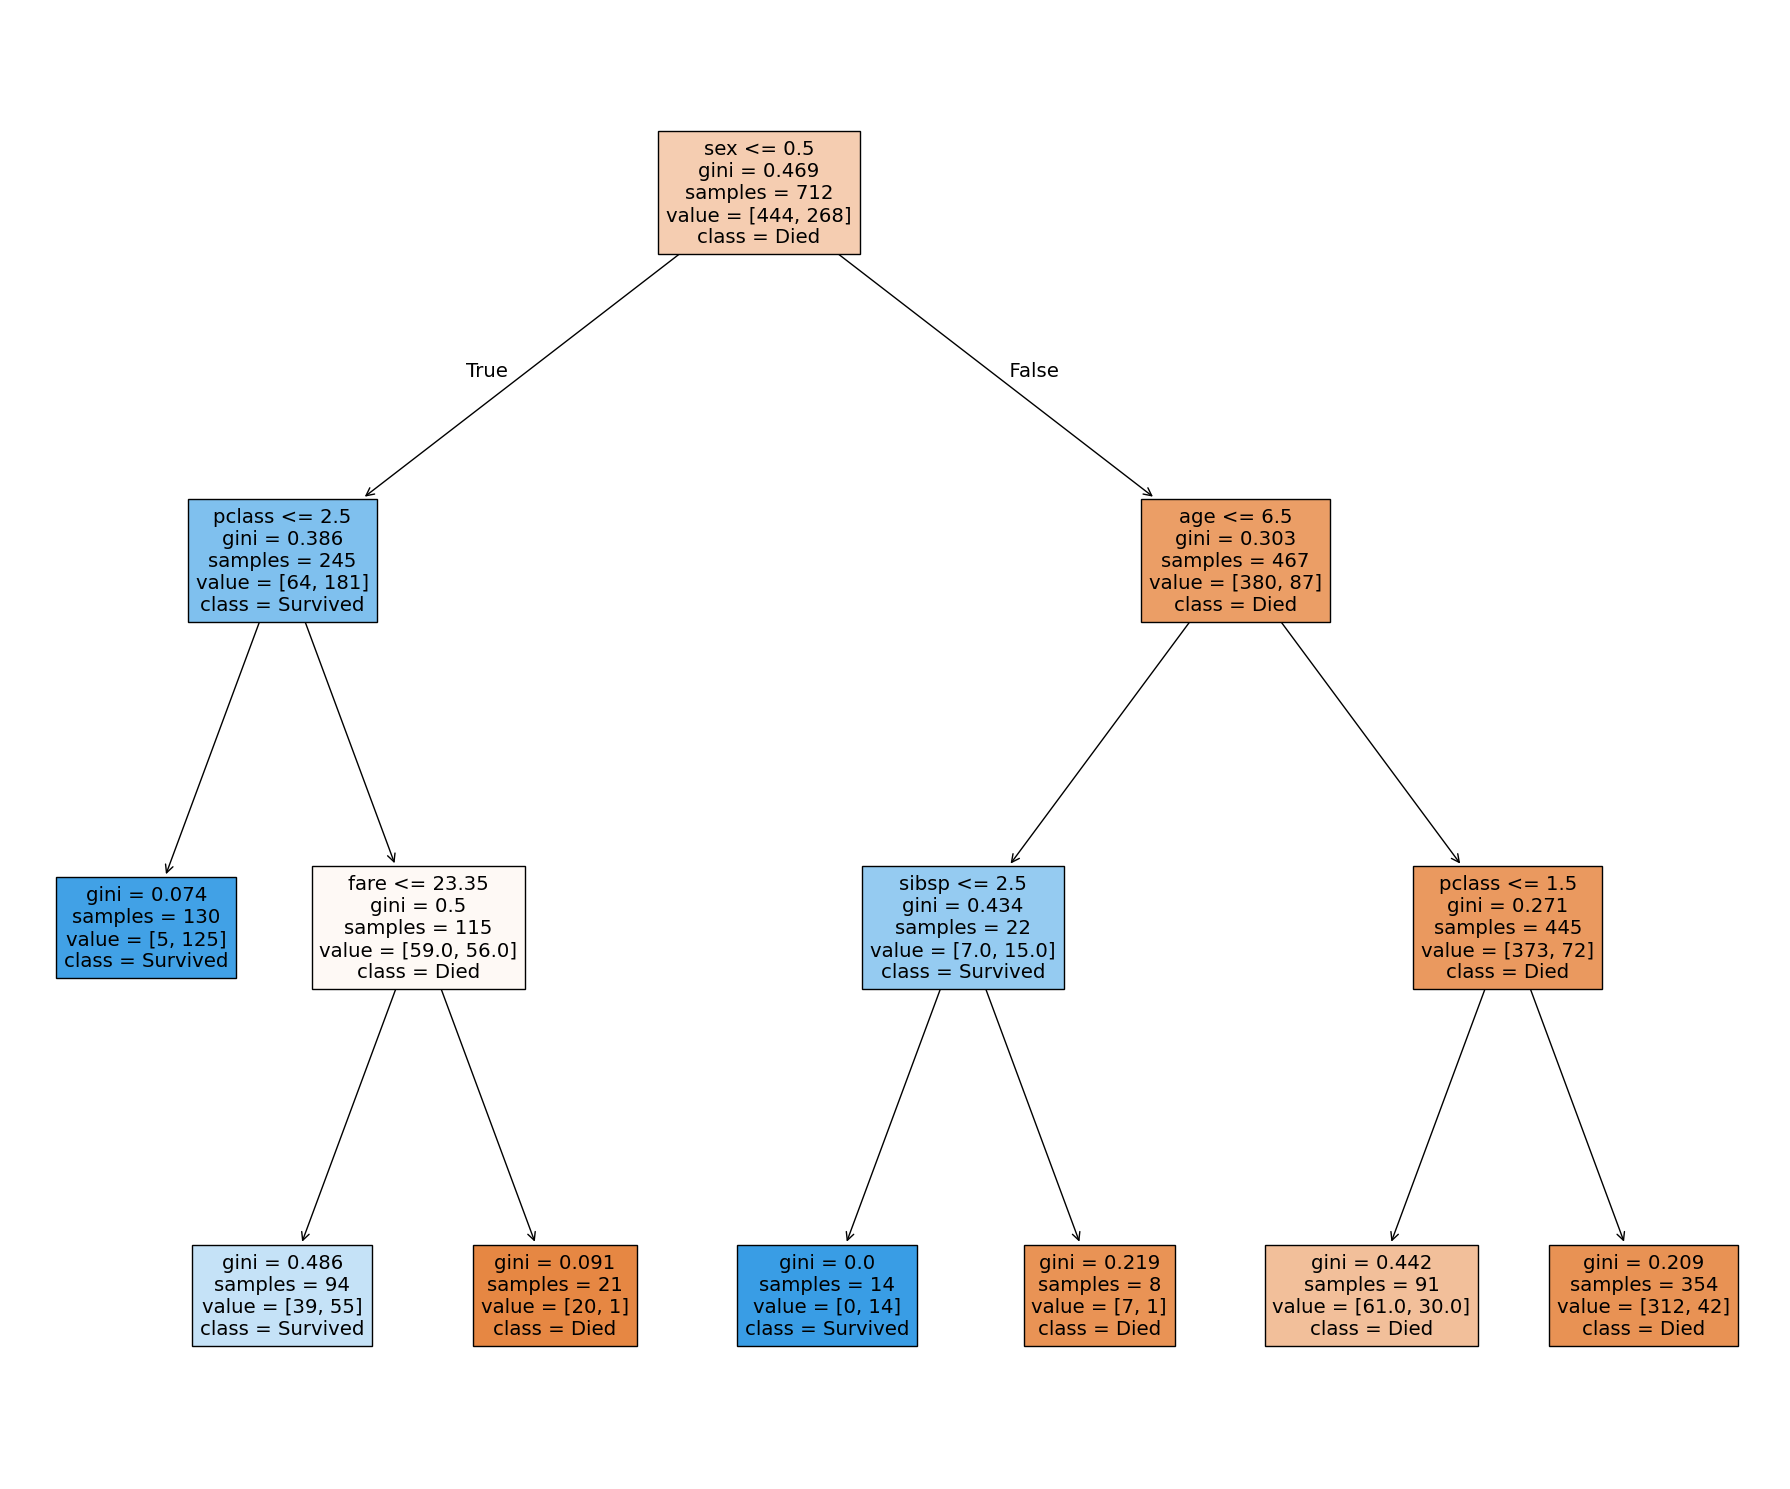

In [195]:
# 1. Train a fully grown, unpruned tree first just to see its structure
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

# 2. Calculate the pruning path to find all the mathematical cut-off points
# we use ccp_alphas to penalise our decision tree model and make it a bit more generalised

# Calculates the mathematical 'breaking points' where increasing the pruning tax forces branches to snap off
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

# Extracts the clean list of these exact tax rates (alphas) to hand over to GridSearchCV for testing
# The higher the alpha value, the more branches get chopped off, and the smaller the tree becomes.
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

# 3. Build a fresh pipeline for Grid Search
steps = [("dt", DecisionTreeClassifier(random_state=42))]
dt_pipeline = Pipeline(steps)

# 4. Set up the parameter grid
param_grid = {
    "dt__ccp_alpha": ccp_alphas # the name of the actual parameter in scikit learn is "ccp_alpha" so we pass that and not "ccp_alphas"
}

# 5. Create GridSearchCV
dt_classifier_cv = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5 # 5-fold cross-validation prevents data leakage
)

# 6. Fit and predict
dt_classifier_cv.fit(X_train, y_train)
y_pred = dt_classifier_cv.predict(X_test)

# 7. Print the results
print("\nBest model (Alpha) : ", dt_classifier_cv.best_params_) # Shows the winning alpha penalty
print("Best Grid Search Accuracy:", dt_classifier_cv.best_score_) # # Shows the top cross-validated score
print("Final Test Accuracy:", dt_classifier_cv.score(X_test, y_test)) # the accuracy of the model on the test data

# 8. Plot the best pruned tree
plt.figure(figsize=(18,15))

# Extract the best trained pipeline from GridSearchCV
best_pipeline = dt_classifier_cv.best_estimator_ 
# Extract the actual Decision Tree classifier from the best pipeline using the string "dt"
best_dt = best_pipeline.named_steps["dt"] 

plot_tree(
    best_dt,
    feature_names = X.columns,
    class_names = ["Died", "Survived"], 
    filled = True,
    max_depth = 3 
)

plt.tight_layout()
plt.show()

## <u>Decision Trees with the mixture of Pre-pruning and Post-Pruning</u>

Best Depth: {'dt__ccp_alpha': np.float64(0.0017280566630421658), 'dt__max_depth': 6, 'dt__min_samples_split': 10}
Best Grid Search Accuracy: 0.8258544272628778
Final Test Accuracy: 0.8044692737430168


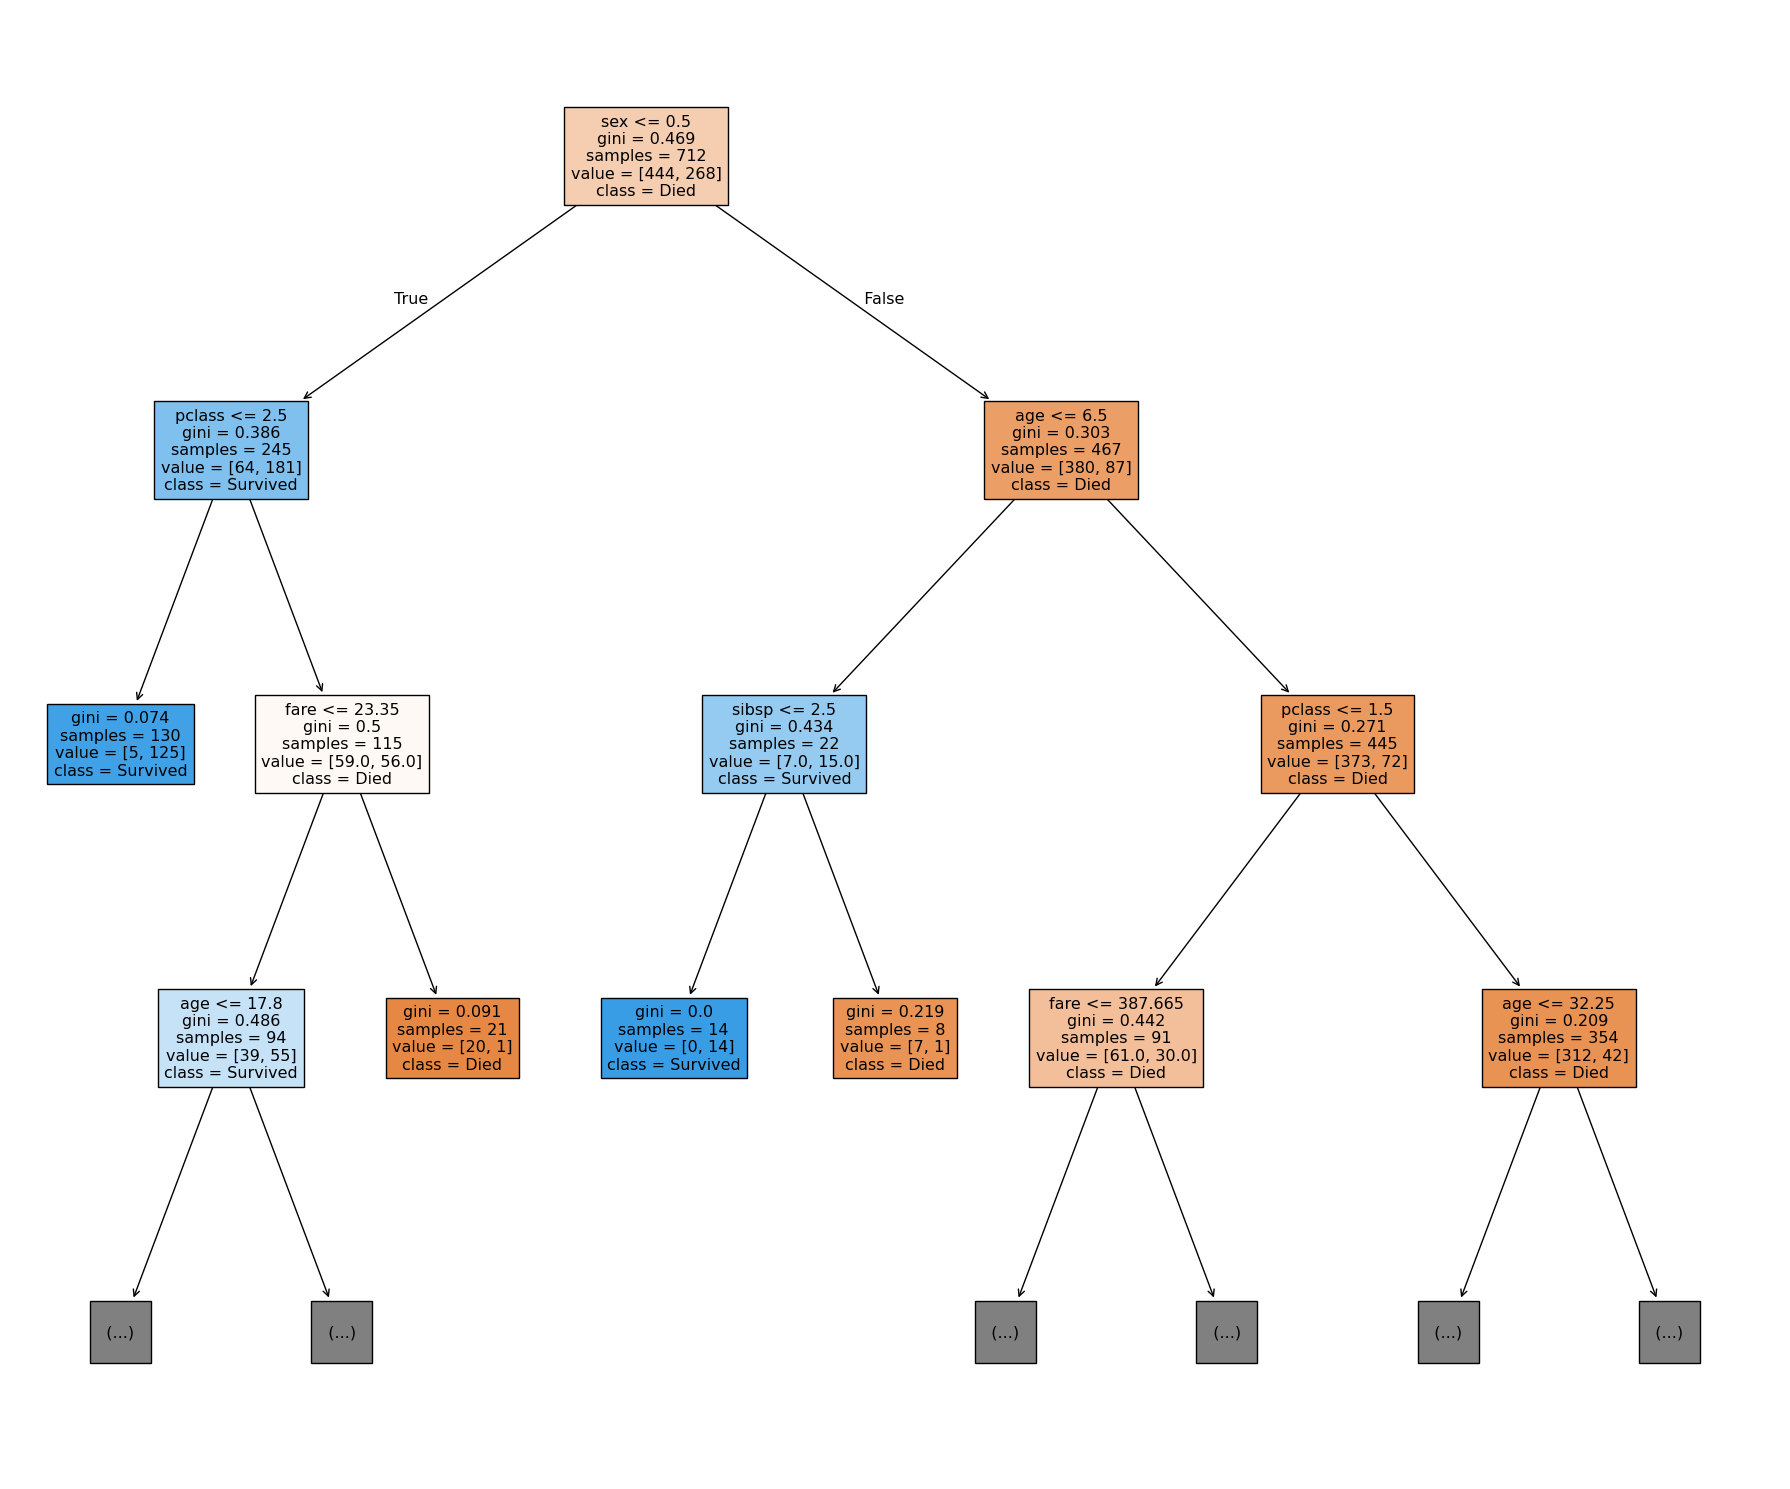

,param_dt__max_depth,param_dt__min_samples_split,param_dt__ccp_alpha,mean_test_score
0,2,5,0.00000,0.786467
1,2,10,0.00000,0.786467
2,2,15,0.00000,0.786467
3,2,20,0.00000,0.786467
4,2,25,0.00000,0.786467
...,...,...,...,...
3451,10,10,0.13778,0.674303
3452,10,15,0.13778,0.674303
3453,10,20,0.13778,0.674303
3454,10,25,0.13778,0.674303


In [199]:
# we use the same process of pipeline, parameter grid and gridsearchcv but we pass both pre-pruning and post-pruning parameters

# 1. Create Train a fully grown, unpruned tree first just to see its structure and get CCP Alpha values
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# 2. make pipeline
steps = [("dt", DecisionTreeClassifier(random_state=42))] # the steps, here random state 42 makes sure there is no randomness
dt_pipeline = Pipeline(steps)

# 3. Set up the parameter grid
param_grid = {
    "dt__max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10], 
    "dt__min_samples_split": [5, 10, 15, 20, 25, 30],
    "dt__ccp_alpha": ccp_alphas
}

# 4. Create the GridSearchCV 
dt_classifier_cv = GridSearchCV(
    dt_pipeline, 
    param_grid, 
    cv=5, # scoring by default is accuracy
)

# 5. Fit and predict
dt_classifier_cv.fit(X_train, y_train)
y_pred = dt_classifier_cv.predict(X_test)

# 6. Print the results
print("Best Depth:", dt_classifier_cv.best_params_) # prints the best max_depth, min_samples_split, CCP-Alpha based on the acc 
print("Best Grid Search Accuracy:", dt_classifier_cv.best_score_) # the accuracy of best max_depth, min_samples_split, CCP-Alpha
print("Final Test Accuracy:", dt_classifier_cv.score(X_test, y_test)) # the accuracy of the model on the test data
                                                                    

# 7. Plot using the extracted tree model
plt.figure(figsize=(18,15))

# using grid search we ran around a lot of pipelines and a lot of models, wee need to select which pipeline, model pair was the best
# Extract the best trained pipeline from GridSearchCV
best_pipeline = dt_classifier_cv.best_estimator_ 
# Extract the actual Decision Tree classifier from the best pipeline using the string "dt"
best_dt = best_pipeline.named_steps["dt"] 

plot_tree(
    best_dt,
    feature_names = X.columns,
    class_names = ["Died", "Survived"], 
    filled = True,
    max_depth = 3
)

plt.tight_layout()
plt.show()

# 8. prints the test score for all the possible combination of max_depth and min_samples_split of the gridsearchcv
pd.DataFrame(dt_classifier_cv.cv_results_)[["param_dt__max_depth", "param_dt__min_samples_split", "param_dt__ccp_alpha", "mean_test_score"]]